# Notebook 04: Three-Class Monospecific Mangrove MLP Classification

## Research Reference
**"An approach for accurate identification and monitoring of species in mangrove forests based on multi-source spectral data and deep learning"**  
*Monterrubio-Martínez, Trujillo-Acatitla, Tuxpan-Vargas, Moreno-Casasola*  
*Ecological Informatics*, Volume 85, 2025, Article 102961. DOI: [10.1016/j.ecoinf.2024.102961](https://doi.org/10.1016/j.ecoinf.2024.102961)

> ### [!WARNING]
> **SCIENTIFIC CLASSIFICATION:**  
> **`DATA-DERIVED EXPERIMENT — NOT DIRECTLY COMPARABLE TO THE PAPER'S REPORTED 4-CLASS RESULTS`**
>
> **Why this distinction is mandatory:**
> - The paper evaluated a **4-class** problem: Class 0 (Non-mangrove), Class 1 (*Rhizophora mangle*), Class 2 (*Avicennia germinans*), and Class 3 (*Laguncularia racemosa*).
> - The authors' publicly deposited dataset `DataBase_Sentinel_2_Mangrove_LaMancha.csv` contains **only the three monospecific mangrove species** (Class 0 is completely absent).
> - Under strict scientific reproduction guidelines, we do **not** synthesize substitute non-mangrove data or claim to have reproduced the paper's 4-class numbers.
> - Instead, this notebook evaluates the paper's architectural family (MLP depths 1–5, widths 5–500, Adam optimizer, ReLU activations) on the **available 3-species monospecific dataset** (30,000 samples: 10,000 per species) to rigorously benchmark inter-species separability.

## Hyperparameter Classification Audit

| Parameter | Value | Scientific Classification |
|---|---|---|
| **Input Spectral Bands** | 10 Sentinel-2 bands | `PAPER-SPECIFIED` |
| **Feature Normalization** | `StandardScaler` (Scikit-learn) | `PAPER-SPECIFIED` |
| **Train / Test Split** | 70% Train (21,000) / 30% Test (9,000) | `PAPER-SPECIFIED` |
| **Hidden Layers** | 1, 2, 3, 4, 5 | `PAPER-SPECIFIED` |
| **Neurons per Layer** | 5, 10, 20, 50, 100, 150, 300, 500 | `PAPER-SPECIFIED` |
| **Hidden Activation** | ReLU | `PAPER-SPECIFIED` |
| **Optimizer Algorithm** | Adam | `PAPER-SPECIFIED` |
| **Learning Rate** | `0.001` | `NOT AVAILABLE` / `IMPLEMENTATION ASSUMPTION` |
| **Batch Size** | `64` | `NOT AVAILABLE` / `IMPLEMENTATION ASSUMPTION` |
| **Epochs** | `50` | `NOT AVAILABLE` / `IMPLEMENTATION ASSUMPTION` |
| **Random Seed** | `42` | `NOT AVAILABLE` / `IMPLEMENTATION ASSUMPTION` |
| **Weight Initialization**| PyTorch Kaiming Uniform | `NOT AVAILABLE` / `IMPLEMENTATION ASSUMPTION` |

In [1]:
import sys
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix

# Ensure project root is in sys.path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import (
    SPECTRAL_BANDS,
    BAND_NAMES,
    SPECIES_NAMES,
    SPECIES_TO_IDX_3CLASS,
    IDX_TO_SPECIES_3CLASS,
    SPECIES_COLORS,
    RANDOM_SEED,
    BATCH_SIZE,
    HIDDEN_LAYERS,
    NEURONS_PER_LAYER,
    RESULTS_MODELS_DIR,
    RESULTS_FIGURES_DIR,
)
from src.data.loader import load_raw_data, sample_balanced_3species, prepare_3species_train_test
from src.models.mlp import create_model, LogisticBaseline, MangroveMLP
from src.training.trainer import set_seed, train_single_model, evaluate_architecture_grid

set_seed(RANDOM_SEED)
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Execution device: {device}")

Execution device: mps


## 1. Prepare Balanced 3-Species Dataset (30,000 Samples)

We sample 10,000 samples for each species and split 70% for training (21,000 samples) and 30% for testing (9,000 samples), scaled with `StandardScaler`.

In [2]:
print("Loading dataset...")
df_raw = load_raw_data()
df_balanced = sample_balanced_3species(df_raw, samples_per_class=10000, random_seed=RANDOM_SEED)

X_train, X_test, y_train, y_test, scaler = prepare_3species_train_test(
    df_balanced, test_size=0.30, random_seed=RANDOM_SEED
)

print(f"Train samples: {X_train.shape[0]:,} (features: {X_train.shape[1]})")
print(f"Test samples:  {X_test.shape[0]:,} (features: {X_test.shape[1]})")
print("Class distribution in Train:", np.bincount(y_train))
print("Class distribution in Test: ", np.bincount(y_test))

Loading dataset...


Train samples: 21,000 (features: 10)
Test samples:  9,000 (features: 10)
Class distribution in Train: [7000 7000 7000]
Class distribution in Test:  [3000 3000 3000]


## 2. Train Logistic Regression Baseline

Section 2.3 notes: *"the initial model consisted of a single input and one output layer, with the sigmoid as the activation function, so that it could be interpreted as a logistic regression."*
For multiclass, this corresponds to a multinomial linear model with Cross-Entropy loss.

In [3]:
logistic_model = create_model(num_hidden_layers=0, neurons_per_layer=0, in_features=10, num_classes=3)
print(logistic_model)

log_res = train_single_model(
    logistic_model, X_train, y_train, X_test, y_test,
    epochs=50, batch_size=BATCH_SIZE, learning_rate=0.001, device=device
)

print(f"Logistic Baseline Train Accuracy: {log_res['train_accuracy']:.4f}")
print(f"Logistic Baseline Test Accuracy:  {log_res['test_accuracy']:.4f}")
print(f"Training Time: {log_res['training_time_seconds']:.2f} seconds")

LogisticBaseline(
  (linear): Linear(in_features=10, out_features=3, bias=True)
)


Logistic Baseline Train Accuracy: 0.6981
Logistic Baseline Test Accuracy:  0.6950
Training Time: 19.47 seconds


## 3. Train Key Representative MLP Architectures

We train key architectures highlighted in the paper:
- 1 Hidden Layer, 500 Neurons
- 2 Hidden Layers, 300 Neurons
- 3 Hidden Layers, 500 Neurons (Peak accuracy in paper)
- 4 Hidden Layers, 300 Neurons
- 5 Hidden Layers, 50 Neurons (Most reliable spatial model in paper)
- 5 Hidden Layers, 300 Neurons

In [4]:
key_configs = [
    (1, 500),
    (2, 300),
    (3, 500),
    (4, 300),
    (5, 50),
    (5, 300),
]

mlp_results = []
trained_models = {}

for layers, neurons in key_configs:
    model_name = f"MLP_{layers}L_{neurons}N"
    print(f"Training {model_name}...")
    model = create_model(num_hidden_layers=layers, neurons_per_layer=neurons, in_features=10, num_classes=3)
    res = train_single_model(
        model, X_train, y_train, X_test, y_test,
        epochs=50, batch_size=BATCH_SIZE, learning_rate=0.001, device=device
    )
    mlp_results.append({
        "Model": model_name,
        "Layers": layers,
        "Neurons": neurons,
        "Train_Accuracy": res["train_accuracy"],
        "Test_Accuracy": res["test_accuracy"],
        "Time_Sec": res["training_time_seconds"],
    })
    trained_models[model_name] = (model, res)
    print(f"  -> Train Acc: {res['train_accuracy']:.4f}, Test Acc: {res['test_accuracy']:.4f}")

df_key_results = pd.DataFrame(mlp_results)
display(df_key_results)

Training MLP_1L_500N...


  -> Train Acc: 0.8813, Test Acc: 0.8748
Training MLP_2L_300N...


  -> Train Acc: 0.9561, Test Acc: 0.9172
Training MLP_3L_500N...


  -> Train Acc: 0.9920, Test Acc: 0.9449
Training MLP_4L_300N...


  -> Train Acc: 0.9910, Test Acc: 0.9422
Training MLP_5L_50N...


  -> Train Acc: 0.9272, Test Acc: 0.9039
Training MLP_5L_300N...


  -> Train Acc: 0.9910, Test Acc: 0.9446


,Model,Layers,Neurons,Train_Accuracy,Test_Accuracy,Time_Sec
0,MLP_1L_500N,1,500,0.881333,0.874778,24.487447
1,MLP_2L_300N,2,300,0.956143,0.917222,34.922910
2,MLP_3L_500N,3,500,0.991952,0.944889,71.437373
3,MLP_4L_300N,4,300,0.991048,0.942222,53.214832
4,MLP_5L_50N,5,50,0.927190,0.903889,48.243495
5,MLP_5L_300N,5,300,0.990952,0.944556,61.659317


## 4. Full Architecture Grid Evaluation (1–5 Layers $\times$ 8 Neuron Widths)

We systematically evaluate the complete 41-model grid (1 Logistic + 40 MLPs) to observe depth vs width scaling on the 3-species monospecific dataset.

In [5]:
print("Evaluating complete 41-architecture grid on 3-species dataset (50 epochs each)...")
grid_results_df = evaluate_architecture_grid(
    X_train, y_train, X_test, y_test,
    epochs=50, batch_size=BATCH_SIZE, learning_rate=0.001, verbose=False
)

# Save results
RESULTS_MODELS_DIR.mkdir(parents=True, exist_ok=True)
grid_results_df.to_csv(RESULTS_MODELS_DIR / "three_class_mangrove_results.csv", index=False)
print("Successfully saved results to results/models/three_class_mangrove_results.csv")
display(grid_results_df.sort_values("Test_Accuracy", ascending=False).head(10))

Evaluating complete 41-architecture grid on 3-species dataset (50 epochs each)...


Successfully saved results to results/models/three_class_mangrove_results.csv


,Model_ID,Architecture_Type,Hidden_Layers,Neurons_Per_Layer,Total_Parameters,Train_Accuracy,Test_Accuracy,Training_Time_Sec
31,MLP_4L_300N,MLP,4,300,275103,0.994810,0.949778,13.295053
24,MLP_3L_500N,MLP,3,500,508003,0.994571,0.947556,13.680585
32,MLP_4L_500N,MLP,4,500,758503,0.989810,0.945222,18.079423
39,MLP_5L_300N,MLP,5,300,365403,0.989524,0.942111,16.202982
38,MLP_5L_150N,MLP,5,150,92703,0.986333,0.940222,9.287346
40,MLP_5L_500N,MLP,5,500,1009003,0.984714,0.939889,22.785803
30,MLP_4L_150N,MLP,4,150,70053,0.982381,0.938444,8.024197
23,MLP_3L_300N,MLP,3,300,184803,0.988524,0.937333,10.386306
37,MLP_5L_100N,MLP,5,100,41803,0.973619,0.931667,8.421495
16,MLP_2L_500N,MLP,2,500,257503,0.979143,0.931667,9.083514


## 5. Confusion Matrix & Per-Class Error Analysis

We evaluate the confusion matrix of the 5-layer, 50-neuron model (the paper's optimal model for spatial generalization).

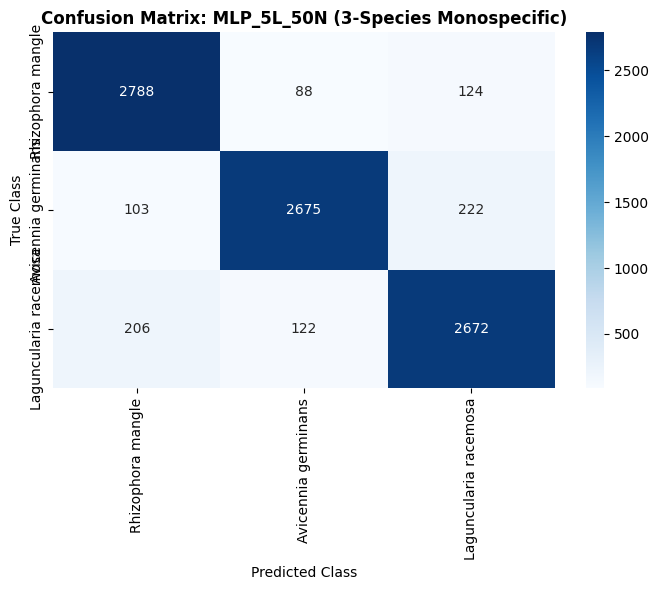


Classification Report:
                       precision    recall  f1-score   support

    Rhizophora mangle     0.9002    0.9293    0.9145      3000
  Avicennia germinans     0.9272    0.8917    0.9091      3000
Laguncularia racemosa     0.8854    0.8907    0.8880      3000

             accuracy                         0.9039      9000
            macro avg     0.9043    0.9039    0.9039      9000
         weighted avg     0.9043    0.9039    0.9039      9000



In [6]:
best_model_name = "MLP_5L_50N"
_, best_res = trained_models[best_model_name]
preds = best_res["test_predictions"]

class_names = [IDX_TO_SPECIES_3CLASS[i].replace("_", " ") for i in range(3)]
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix: {best_model_name} (3-Species Monospecific)", fontsize=12, fontweight="bold")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.savefig(RESULTS_FIGURES_DIR / "three_class_confusion_matrix.png", dpi=300)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, preds, target_names=class_names, digits=4))